In [1]:
import sys

sys.path.insert(0, "..")

import librosa
from pathlib import Path
from IPython.display import Audio

import pygaborstm as stm

print(f"PyGaborSTM version: {stm.__version__}")

PyGaborSTM version: 0.1.0


In [2]:
# %% Load audio file
filepath = Path("notebooks/assets/hello_world.wav")

audio, sr = librosa.load(filepath, sr=16000)

print(f"Loaded: {filepath.name}")
print(f"Audio shape: {audio.shape}, SR: {sr}")
print(f"Duration: {len(audio) / sr:.2f}s")

Audio(audio, rate=sr)

Loaded: hello_world.wav
Audio shape: (18391,), SR: 16000
Duration: 1.15s


In [3]:
# Compute auditory spectrogram
spec_model = stm.AuditorySpectrogram()
spectrogram = spec_model.compute(audio)

print("\n=== Spectrogram Stats ===")
print(f"Shape: {spectrogram.shape}")
print(f"Min: {spectrogram.data.min():.6f}")
print(f"Max: {spectrogram.data.max():.6f}")
print(f"Mean: {spectrogram.data.mean():.6f}")
print(f"Std: {spectrogram.data.std():.6f}")
print(f"Time range: {spectrogram.times[0]:.3f}s - {spectrogram.times[-1]:.3f}s")
print(f"Freq range: {spectrogram.freqs[0]:.1f}Hz - {spectrogram.freqs[-1]:.1f}Hz")

print("\nFirst 5x5 corner:")
print(spectrogram.data[:5, :5])


=== Spectrogram Stats ===
Shape: (256, 144)
Min: 0.000000
Max: 0.269632
Mean: 0.058239
Std: 0.043825
Time range: 0.000s - 1.144s
Freq range: 180.0Hz - 7091.4Hz

First 5x5 corner:
[[0.0035496  0.0040066  0.00481256 0.00463916 0.0021094 ]
 [0.00356361 0.00381832 0.00523448 0.00440154 0.00215309]
 [0.00355505 0.00360171 0.00545469 0.00402282 0.00242928]
 [0.0035213  0.00335337 0.0054629  0.00348687 0.00203908]
 [0.00346422 0.00312178 0.00531211 0.00314634 0.00265208]]


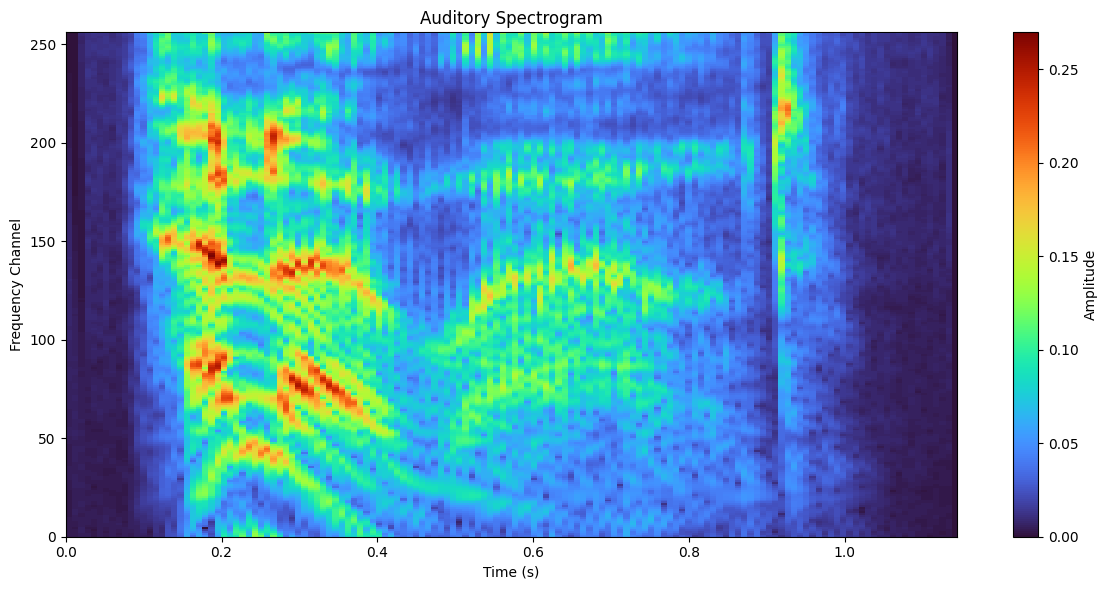

In [4]:
# Plot spectrogram
stm.plot_spectrogram(spectrogram, titles="Auditory Spectrogram")

In [5]:
# Compute RSF representation
gabor_model = stm.GaborFilterbank()
rsf = gabor_model.compute(spectrogram)

print("\n=== RSF Stats ===")
print(f"Shape: {rsf.shape}")
print(f"  - n_frames: {rsf.n_frames}")
print(f"  - n_rates: {rsf.n_rates}")
print(f"  - n_scales: {rsf.n_scales}")
print(f"  - n_freqs: {rsf.n_freqs}")
print(f"Min: {rsf.data.min():.6f}")
print(f"Max: {rsf.data.max():.6f}")
print(f"Rates: {rsf.rates}")
print(f"Scales: {rsf.scales}")


=== RSF Stats ===
Shape: (83, 10, 6, 256)
  - n_frames: 83
  - n_rates: 10
  - n_scales: 6
  - n_freqs: 256
Min: 0.089758
Max: 35.727785
Rates: [-32. -16.  -8.  -4.  -2.   2.   4.   8.  16.  32.]
Scales: [0.25 0.5  1.   2.   4.   8.  ]


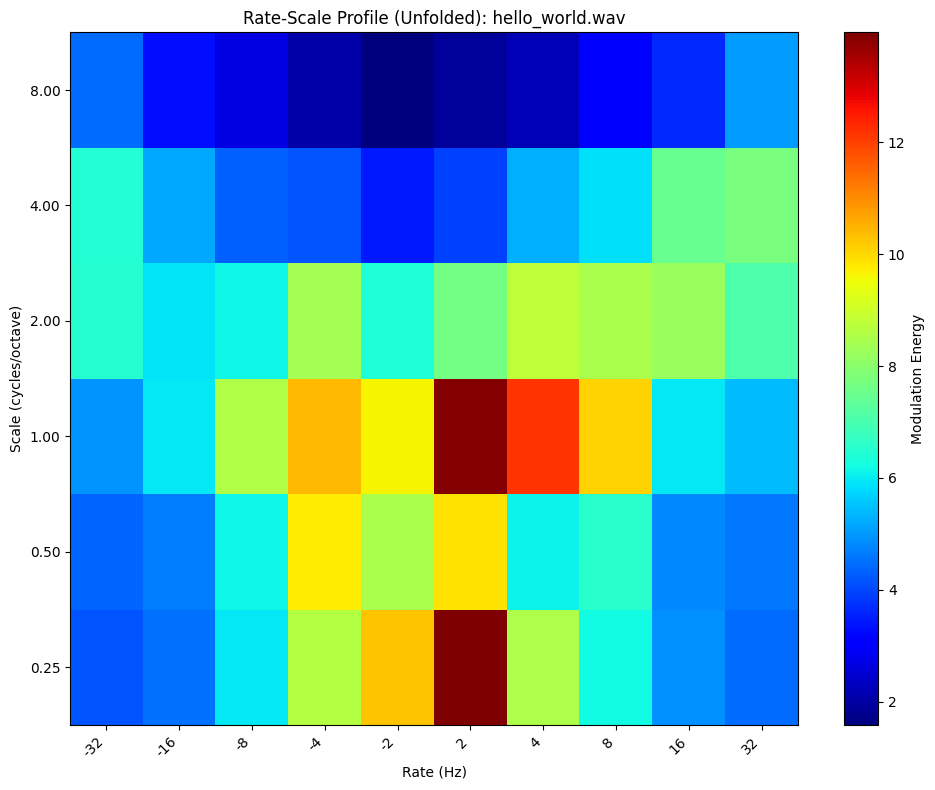

In [6]:
# Plot RSF - unfolded
stm.plot_rsf(rsf, title=f"Rate-Scale Profile (Unfolded): {filepath.name}")

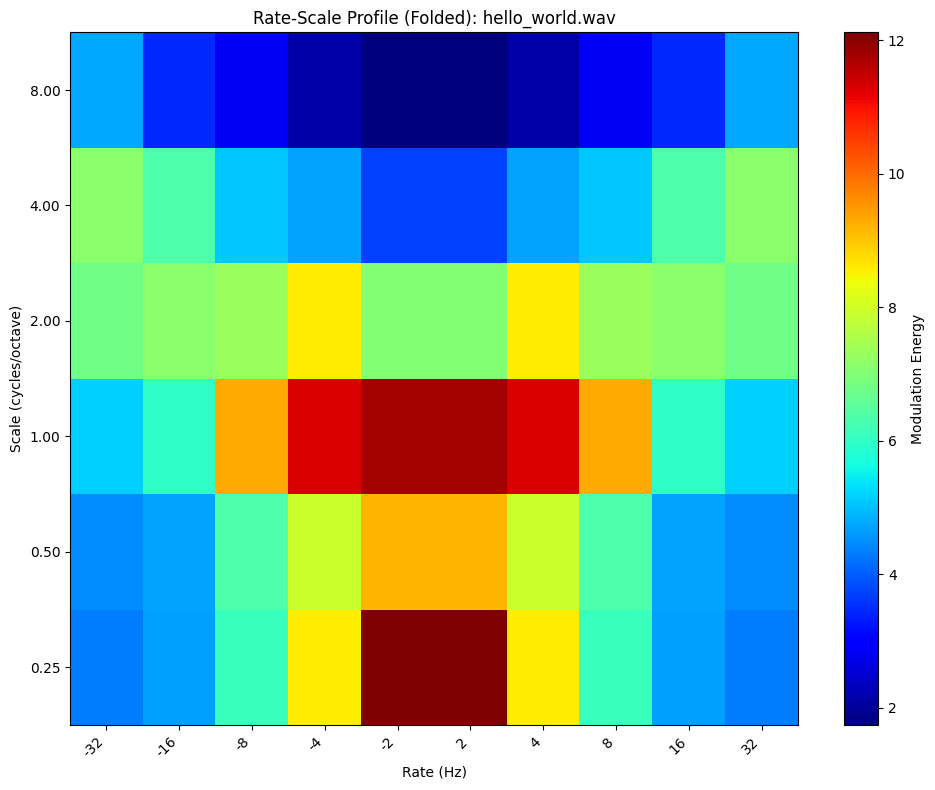

In [7]:
# Plot RSF - folded (symmetric)
stm.plot_rsf(rsf, fold=True, title=f"Rate-Scale Profile (Folded): {filepath.name}")

In [8]:
# Alternative: use the convenience function for the full pipeline
rsf_direct = stm.compute_rsf(audio, sr=sr)
print(f"Direct RSF shape: {rsf_direct.shape}")

Direct RSF shape: (83, 10, 6, 256)


In [9]:
# Access rate-scale matrix directly
rs_matrix = rsf.rate_scale_matrix(fold=False)
rs_folded = rsf.rate_scale_matrix(fold=True)
print(f"Rate-scale matrix shape: {rs_matrix.shape}")
print(f"Folded matrix shape: {rs_folded.shape}")

Rate-scale matrix shape: (6, 10)
Folded matrix shape: (6, 10)
